In [1]:
import pandas as pd

In [2]:
from Descriptive import Descriptive

In [3]:
obj=Descriptive()

In [4]:
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS" #NSE stocks usually end with .NS
#dowload the stock data from NSE
stk_data=yf.download(stock_symbol, start="2024-05-01", end="2025-10-09")

[*********************100%***********************]  1 of 1 completed


In [5]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 358 entries, 2024-05-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   358 non-null    float64
 1   (High, RELIANCE.NS)    358 non-null    float64
 2   (Low, RELIANCE.NS)     358 non-null    float64
 3   (Open, RELIANCE.NS)    358 non-null    float64
 4   (Volume, RELIANCE.NS)  358 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.8 KB


In [6]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [7]:
stk_data

Price,Open,High,Low,Close
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2024-05-02,1454.460207,1459.721708,1446.679042,1449.075195
2024-05-03,1453.472210,1457.375095,1399.275803,1416.913086
2024-05-06,1418.395221,1422.841601,1401.103743,1402.610596
2024-05-07,1399.102859,1403.820987,1375.413559,1384.775635
2024-05-08,1380.847991,1415.875536,1380.847991,1401.647217
...,...,...,...,...
2025-10-01,1360.708629,1372.255218,1356.428371,1362.400757
2025-10-03,1356.926092,1365.287457,1350.655159,1357.125244


In [8]:
column="Close"

In [9]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (358, 1)


In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [11]:
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(data1, order=i)
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(0, len(data1)-1)
    #print(y_pred)
    from stockFunctions1 import rmsemape
    rmsemape(data1,y_pred)

RMSE-Testset: 0.05685553032609588
MAPE-Testset: 289328540883.9765
RMSE-Testset: 0.056852748679553006
MAPE-Testset: 286978751162.1403


C:\Users\manju\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\manju\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


RMSE-Testset: 0.07514299166184386
MAPE-Testset: 25272328976.101513


C:\Users\manju\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\manju\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


RMSE-Testset: 0.061387364725337255
MAPE-Testset: 241883267741.37457


In [12]:
len(y_pred)

358

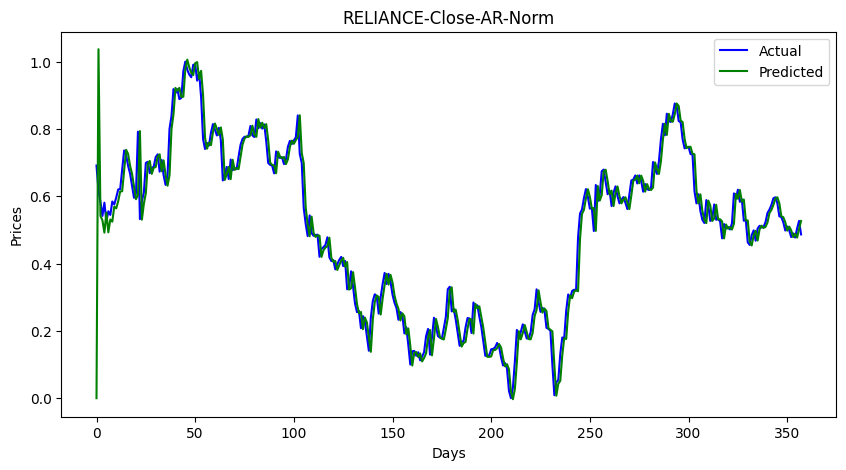

In [13]:
from stockFunctions1 import graph
graph(data1,y_pred,"Actual","Predicted","RELIANCE-Close-AR-Norm","Days","Prices")

In [14]:
len(data1)

358

In [15]:
from stockFunctions1 import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [16]:
from stockFunctions1 import conversionSingle
pTestNormTable=conversionSingle(data1,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

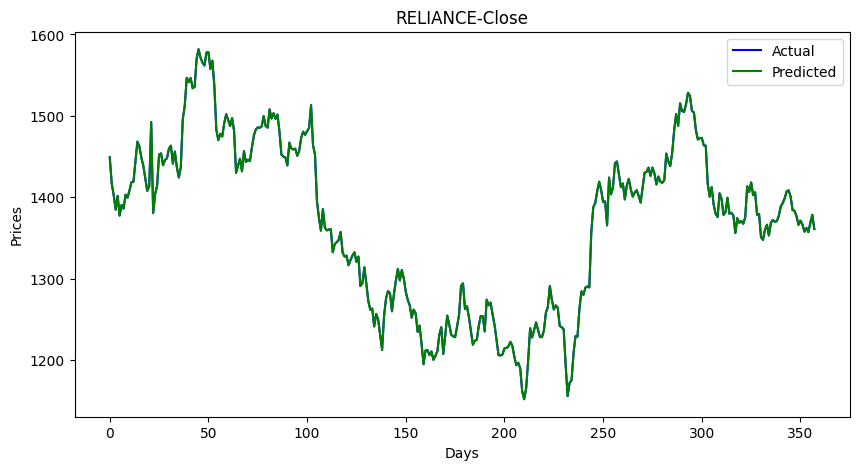

In [17]:
from stockFunctions1 import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","RELIANCE-Close","Days","Prices")

In [18]:
from stockFunctions1 import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 0.0
MAPE-Testset: 0.0


In [19]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [20]:
from stockFunctions1 import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [21]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [22]:
forecast_stock_price_test_oriF

,Closefore
0,1361.129052
1,1360.889212
2,1360.688985
3,1360.455535
